In [1]:
import numpy as np
import tifffile
from sklearn.cluster import KMeans
import io
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

from IPython.display import Image as IPyImage, display
from helper import *

In [2]:
tiff_path = "Greyscale/EFSGP01_00.tif"

with tifffile.TiffFile(tiff_path) as tif:
    shape = tif.series[0].shape
    print(f"Image dimensions: {shape}")
    print(f"Data type: {tif.series[0].dtype}")
        
    depth, height, width = shape
            
    print(f"Depth (Z): {depth}, Height (Y): {height}, Width (X): {width}")

region, (start_z, start_y, start_x) = read_voxel_region(tiff_path)
np.unique(region)

Image dimensions: (1600, 1400, 1400)
Data type: uint16
Depth (Z): 1600, Height (Y): 1400, Width (X): 1400
Reading region: Z[726:826], Y[618:718], X[668:768]


array([10984, 11177, 11211, ..., 52842, 52874, 52927], dtype=uint16)

In [4]:
def normalize_image(imgs):
    
    # on garde que les valeurs positives pour la normalisation
    positive_vals = imgs[imgs > 0]
    mu = np.mean(positive_vals)
    sigma = np.std(positive_vals)
    
    # on mets la normalisation 
    norm_imgs = (imgs - mu) / (5 * sigma)
    
    # Remettre à zéro les valeurs initialement nulles
    norm_imgs[imgs == 0] = 0
    return norm_imgs

data = normalize_image(region)
np.unique(data)

array([-0.4562018 , -0.45300382, -0.45244045, ...,  0.2373784 ,
        0.23790863,  0.23878683])

We initially explored DBSCAN because it has several appealing properties for unsupervised segmentation. Most notably, it does not require specifying the number of clusters in advance — an advantage in our problem, where the number of grains in each extracted 3D zone is unknown and variable. DBSCAN can also detect clusters of arbitrary shape and automatically identify noise, which seemed useful for segmenting potentially irregular or disconnected grain structures.

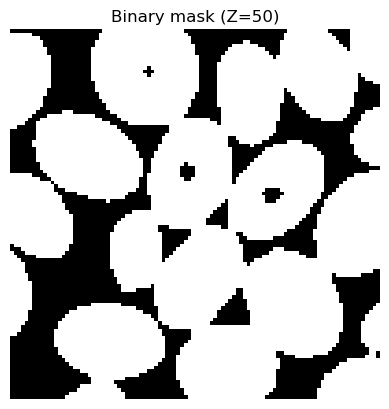

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Show middle slice along z-axis
z_slice = data.shape[0] // 2
binary_slice = np.where(data[z_slice] > 0, 1, 0)

plt.imshow(binary_slice, cmap='gray')
plt.title(f"Binary mask (Z={z_slice})")
plt.axis('off')
plt.show()

In [13]:
# Option: create a binary mask beforehand, e.g., from KMeans or thresholding
binary_mask = data > 0 # or (segmented == 1)

# Get foreground voxel coordinates
coords = np.array(np.where(binary_mask)).T  # shape: (n_voxels, 3)

# Optional: add intensity as a 4th feature
intensities = data[binary_mask].reshape(-1, 1)
features = np.concatenate([coords, intensities], axis=1)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [25]:
dbscan = DBSCAN(eps=0.5, min_samples=20)  # tune eps and min_samples
labels = dbscan.fit_predict(features_scaled)

# Labels are: -1 = noise, 0-N = cluster IDs
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Found {num_clusters} clusters with DBSCAN")

Found 1 clusters with DBSCAN


In [26]:
label_volume = np.zeros_like(data, dtype=np.int32)
label_volume[tuple(coords.T)] = labels + 1  # shift to make noise = 0, clusters start from 1

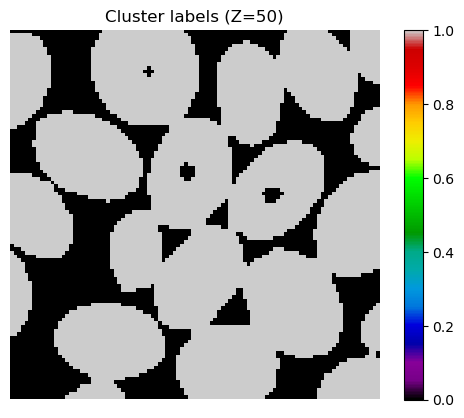

In [27]:
import matplotlib.pyplot as plt

z = 50  # choose desired z-slice
slice_2d = label_volume[z]  # labeled mask: 0 = background, others = clusters

plt.imshow(slice_2d, cmap='nipy_spectral')
plt.title(f"Cluster labels (Z={z})")
plt.axis('off')
plt.colorbar()
plt.show()

In practice, DBSCAN proved unsuitable for segmenting individual grains. Since many grains in the volume are touching or closely packed, DBSCAN often merges them into a single cluster. This is because it groups points based solely on density and proximity, without considering object boundaries or shapes. As a result, it struggles to separate individual grains when there are no clear spatial gaps between them.